# Capstone Project: Billboard Hot 100 Analysis
# Author: Ian Dunn

**Dataset Download Instructions**

To run this notebook, download `Hot Stuff.csv` and `Hot 100 Audio Features.csv` from the "Billboard Hot weekly charts" dataset on Kaggle:
https://www.kaggle.com/datasets/thedevastator/billboard-hot-100-audio-features
Place these two CSV files in the same directory as this notebook.

In [1]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
import seaborn as sns

df_billboard = pd.read_csv('Hot Stuff.csv') #Billboard Hot 100 chart history
df_audio = pd.read_csv('Hot 100 Audio Features.csv') #Spotify audio data, including track duration
df = pd.merge(df_billboard, df_audio, on='SongID')

df['duration_mins'] = df['spotify_track_duration_ms'] / 60000
df['WeekID'] = pd.to_datetime(df['WeekID'])
df['year'] = df['WeekID'].dt.year

#Flattens the time-series data, collapsing chart instances into summary metrics
song_profiles = df.groupby('SongID').agg(song=('Song_x', 'first'), performer=('Performer_x', 'first'), 
                                            duration_mins=('duration_mins', 'first'), 
                                            peak_position=('Peak Position', 'min'), 
                                            weeks_on_chart=('SongID', 'count'), first_year=('year', 'min')
                                            ).reset_index()
song_profiles = song_profiles.dropna(subset=['duration_mins'])
yearly_avg_duration = song_profiles.groupby('first_year')['duration_mins'].mean().reset_index()

# Exploratory Data Analysis
Below are visualizations showing the historical trend of song lengths and chart longevity since 1965 and distribution of song lengths.

Correlation of Duration vs. Weeks on Chart: 0.1544
P-value of Duration vs. Weeks on Chart: 2.0750e-129

Correlation of Duration vs. Peak Position: -0.0514
P-value of Duration vs. Peak Position: 1.1321e-15


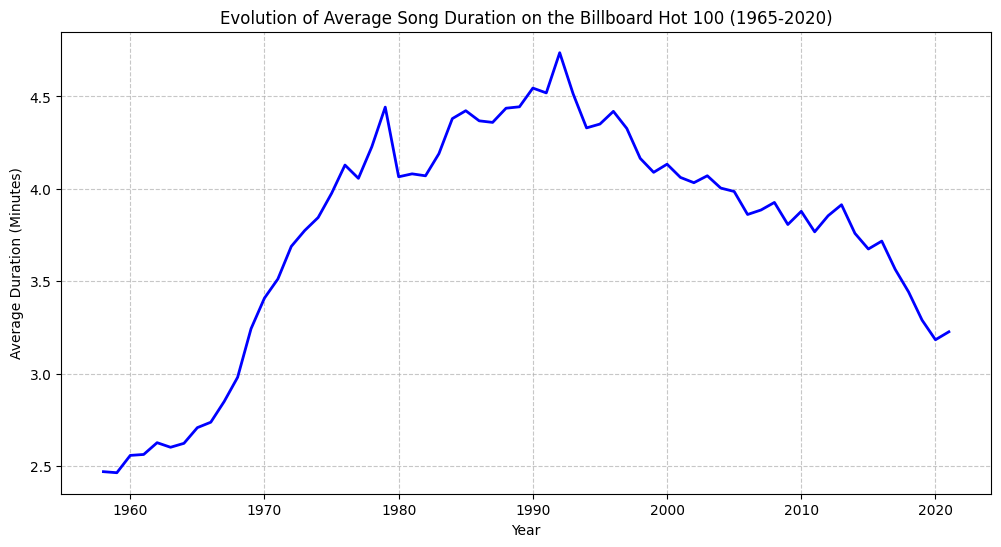

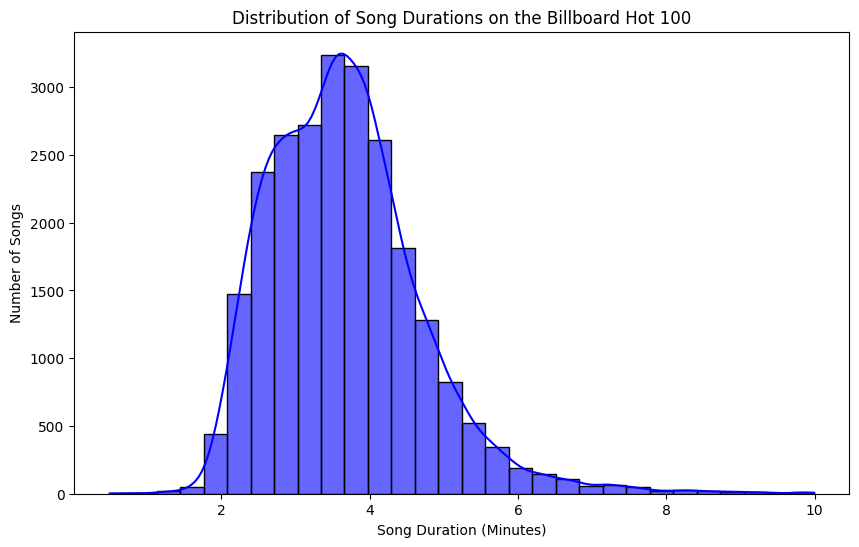

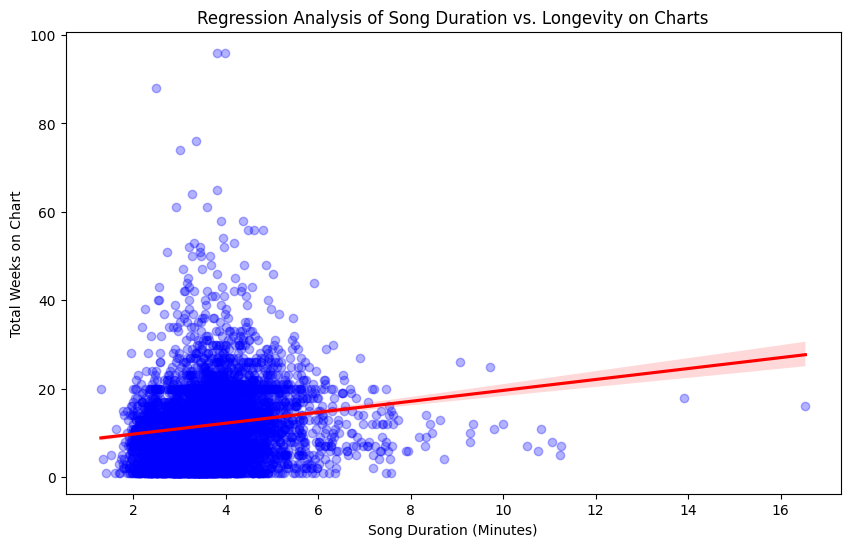

In [2]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_avg_duration, x='first_year', y='duration_mins', color='blue', linewidth=2)
plt.title('Evolution of Average Song Duration on the Billboard Hot 100 (1965-2020)')
plt.xlabel('Year')
plt.ylabel('Average Duration (Minutes)')
plt.grid(True, linestyle='--', alpha=.7)
plt.savefig('Song_Duration_Trend.png', dpi=300, bbox_inches='tight')

#Ignores extreme outliers such as songs up to 50 minutes long
filtered_profiles = song_profiles[song_profiles['duration_mins'] <= 10]

plt.figure(figsize=(10, 6))
sns.histplot(data=filtered_profiles, x='duration_mins', bins=30, color='blue', kde=True, alpha=.6)
plt.title('Distribution of Song Durations on the Billboard Hot 100')
plt.xlabel('Song Duration (Minutes)')
plt.ylabel('Number of Songs')
plt.savefig('Song_Duration_Distribution.png', dpi=300, bbox_inches='tight')

#Establishes baseline linear relationships
correlation_longevity, p_val_longevity = stats.pearsonr(song_profiles['duration_mins'], song_profiles['weeks_on_chart'])
print(f"Correlation of Duration vs. Weeks on Chart: {correlation_longevity:.4f}")
print(f"P-value of Duration vs. Weeks on Chart: {p_val_longevity:.4e}")

correlation_peak, p_val_peak = stats.pearsonr(song_profiles['duration_mins'], song_profiles['peak_position'])
print(f"\nCorrelation of Duration vs. Peak Position: {correlation_peak:.4f}")
print(f"P-value of Duration vs. Peak Position: {p_val_peak:.4e}")

plt.figure(figsize=(10, 6))

#Smaller sample for the scatter plot to mitigate overplotting and improve render speed
sample_data = song_profiles.sample(n=min(5000, len(song_profiles)), random_state=42)

sns.regplot(data=sample_data, x='duration_mins', y='weeks_on_chart', scatter_kws={'alpha':.3, 'color':'blue'},
            line_kws={'color':'red'})
plt.title('Regression Analysis of Song Duration vs. Longevity on Charts')
plt.xlabel('Song Duration (Minutes)')
plt.ylabel('Total Weeks on Chart')
plt.savefig('Duration_vs_Longevity.png', dpi=300, bbox_inches='tight')

# Machine Learning Linear Regression
To test if duration predicts longevity, a Linear Regression model is applied below.


Linear Regression Model Analysis
R-squared: 0.0232
Mean Squared Error: 75.2137
Model Coefficient (Slope): 1.1971


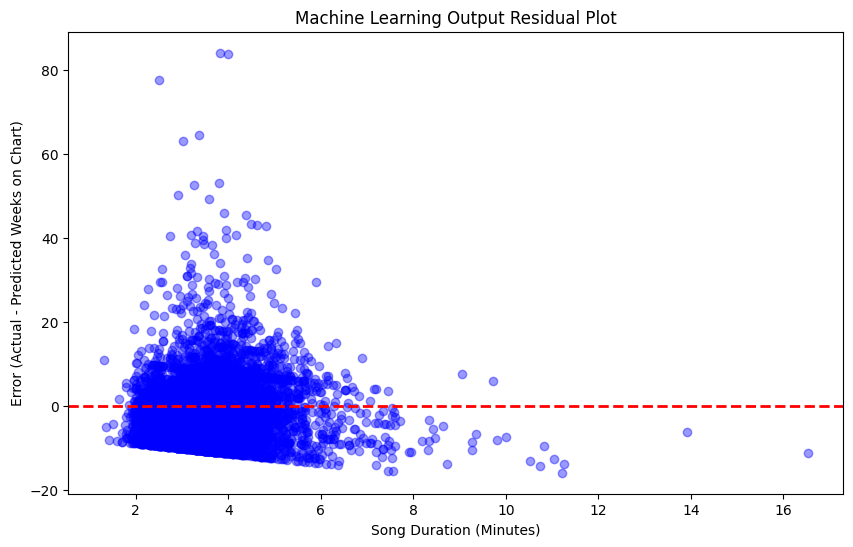

In [3]:
#Single-variable linear regression to quantify the variance in chart longevity explained by song duration
X = song_profiles[['duration_mins']]
y = song_profiles['weeks_on_chart']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42)
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("\nLinear Regression Model Analysis")
print(f"R-squared: {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"Model Coefficient (Slope): {lr_model.coef_[0]:.4f}")

plt.figure(figsize=(10, 6))

residuals = y_test - y_pred

#Plots residuals to evaluate variance between actual data and predictions
plt.scatter(X_test, residuals, color='blue', alpha=.4)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Machine Learning Output Residual Plot')
plt.xlabel('Song Duration (Minutes)')
plt.ylabel('Error (Actual - Predicted Weeks on Chart)')
plt.savefig('ML_Residual_Plot.png', dpi=300, bbox_inches='tight')